In [2]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# 1. Load lại mô hình
model = XGBClassifier()
model.load_model('../models/xgboost_risk_model.json')

# 2. Load lại dữ liệu và tách X
df = pd.read_csv('../data/processed/df_final_prepared.csv')
X = df.drop(columns=['id_student', 'code_module', 'code_presentation', 'is_Risk'])

print("✅ Đã sẵn sàng dữ liệu và mô hình cho SHAP!")

✅ Đã sẵn sàng dữ liệu và mô hình cho SHAP!


In [3]:
# Khởi tạo TreeExplainer chuyên dụng cho XGBoost
explainer = shap.TreeExplainer(model)

# Tính toán SHAP values cho toàn bộ tập X
shap_values = explainer.shap_values(X)

print("✅ Đã tính toán xong SHAP values!")

✅ Đã tính toán xong SHAP values!


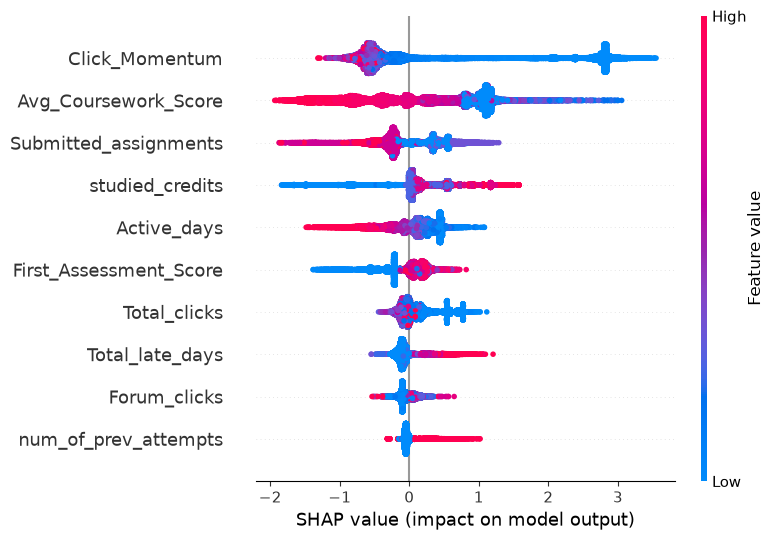

In [5]:
shap.summary_plot(shap_values, X, plot_type="dot")

--- Đang phân tích hồ sơ sinh viên ở dòng số 99 ---


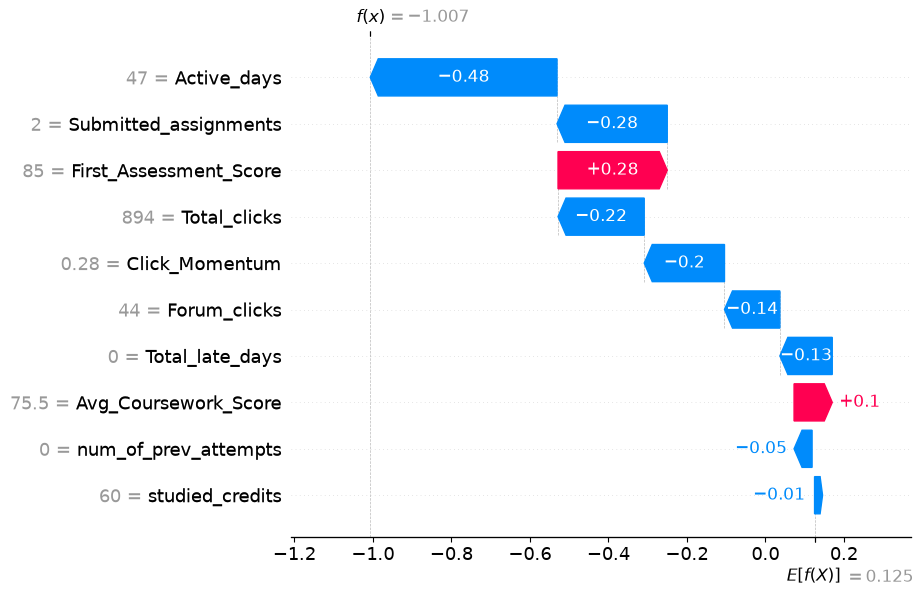

In [7]:
# Lưu ý: Hàm waterfall cần đối tượng Explanation chuẩn mới của thư viện SHAP
# Chúng ta sẽ tính toán lại nhanh bằng explainer() thay vì explainer.shap_values()
shap_values_explanation = explainer(X)

# 1. Chọn một sinh viên để "lên thớt" phân tích
# Bạn có thể đổi con số này (ví dụ: 0, 10, 99) để xem các sinh viên khác nhau
student_index = 99  

print(f"--- Đang phân tích hồ sơ sinh viên ở dòng số {student_index} ---")

# 2. Vẽ biểu đồ Waterfall
shap.plots.waterfall(shap_values_explanation[student_index])